# Exploratory Data Analysis (EDA)

This notebook explores the preprocessed financial time-series data.

Goals:
- Understand price behavior and volatility
- Compare TSLA with SPY and BND
- Test stationarity assumptions
- Build intuition for ARIMA and LSTM modeling


In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.tsa.stattools import adfuller

%matplotlib inline


In [3]:
ROOT_DIR = os.path.abspath(os.path.join(".."))
DATA_DIR = os.path.join(ROOT_DIR, "data", "processed")

df = pd.read_csv(
    os.path.join(DATA_DIR, "combined.csv"),
    index_col=0,
    parse_dates=True
)

df.head()


,TSLA_adjclose,TSLA_return,TSLA_vol,SPY_adjclose,SPY_return,SPY_vol,BND_adjclose,BND_return,BND_vol
Date,,,,,,,,,
2015-01-02,14.620667,NaN,NaN,170.589584,NaN,NaN,60.385963,NaN,NaN
2015-01-05,14.006000,-0.042041,NaN,167.508820,-0.018060,NaN,60.561306,0.002904,NaN
2015-01-06,14.085333,0.005664,NaN,165.931076,-0.009419,NaN,60.736687,0.002896,NaN
2015-01-07,14.063333,-0.001562,NaN,167.998734,0.012461,NaN,60.773228,0.000602,NaN
2015-01-08,14.041333,-0.001564,NaN,170.979904,0.017745,NaN,60.678238,-0.001563,NaN


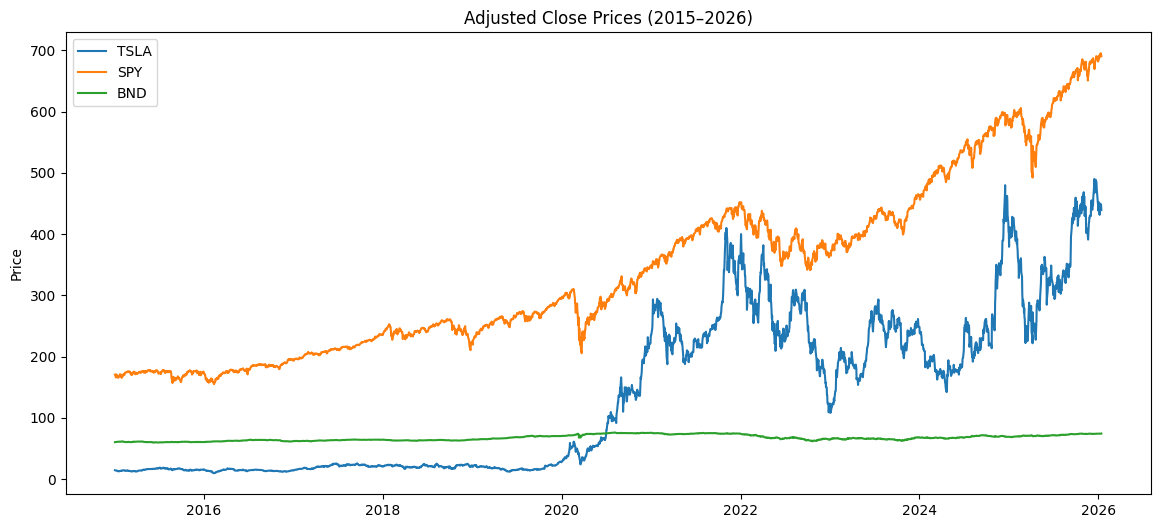

In [4]:
plt.figure(figsize=(14, 6))
plt.plot(df.index, df["TSLA_adjclose"], label="TSLA")
plt.plot(df.index, df["SPY_adjclose"], label="SPY")
plt.plot(df.index, df["BND_adjclose"], label="BND")

plt.title("Adjusted Close Prices (2015–2026)")
plt.ylabel("Price")
plt.legend()
plt.show()


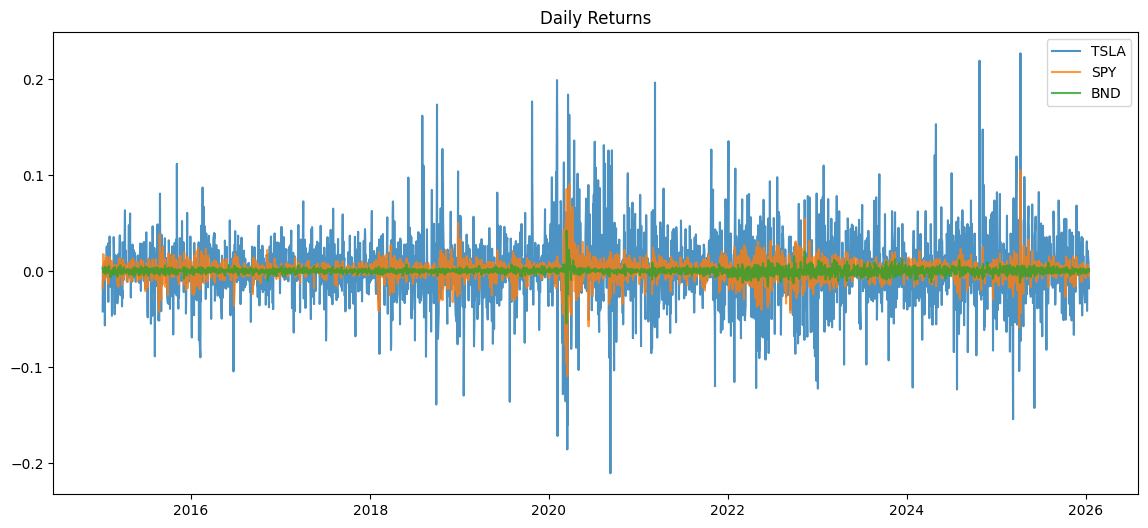

In [5]:
plt.figure(figsize=(14, 6))
plt.plot(df.index, df["TSLA_return"], label="TSLA", alpha=0.8)
plt.plot(df.index, df["SPY_return"], label="SPY", alpha=0.8)
plt.plot(df.index, df["BND_return"], label="BND", alpha=0.8)

plt.title("Daily Returns")
plt.legend()
plt.show()


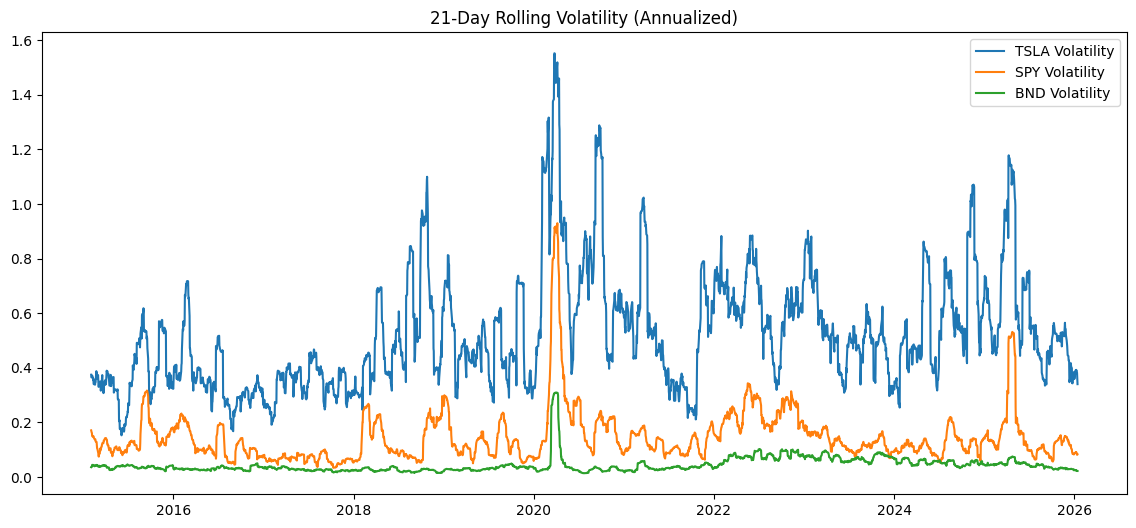

In [6]:
plt.figure(figsize=(14, 6))
plt.plot(df.index, df["TSLA_vol"], label="TSLA Volatility")
plt.plot(df.index, df["SPY_vol"], label="SPY Volatility")
plt.plot(df.index, df["BND_vol"], label="BND Volatility")

plt.title("21-Day Rolling Volatility (Annualized)")
plt.legend()
plt.show()


In [7]:
def adf_test(series, name=""):
    series = series.dropna()
    result = adfuller(series)

    print(f"ADF Test — {name}")
    print(f"ADF Statistic: {result[0]:.4f}")
    print(f"p-value: {result[1]:.4f}")

    for key, value in result[4].items():
        print(f"Critical Value ({key}): {value:.4f}")

    if result[1] < 0.05:
        print("→ Stationary (reject H0)")
    else:
        print("→ Non-stationary (fail to reject H0)")

    print("-" * 40)


In [8]:
adf_test(df["TSLA_adjclose"], "TSLA Price")
adf_test(df["TSLA_return"], "TSLA Returns")

ADF Test — TSLA Price
ADF Statistic: -0.9711
p-value: 0.7637
Critical Value (1%): -3.4326
Critical Value (5%): -2.8626
Critical Value (10%): -2.5673
→ Non-stationary (fail to reject H0)
----------------------------------------
ADF Test — TSLA Returns
ADF Statistic: -54.1475
p-value: 0.0000
Critical Value (1%): -3.4326
Critical Value (5%): -2.8625
Critical Value (10%): -2.5673
→ Stationary (reject H0)
----------------------------------------


In [9]:
def historical_var(returns, alpha=0.05):
    returns = returns.dropna()
    return np.percentile(returns, 100 * alpha)

def sharpe_ratio(returns, periods=252):
    mean = returns.mean() * periods
    std = returns.std() * np.sqrt(periods)
    return mean / std

for asset in ["TSLA", "SPY", "BND"]:
    r = df[f"{asset}_return"]
    print(f"{asset}")
    print(f"  VaR (5%): {historical_var(r):.4f}")
    print(f"  Sharpe: {sharpe_ratio(r):.4f}")
    print()


TSLA
  VaR (5%): -0.0513
  Sharpe: 0.8081

SPY
  VaR (5%): -0.0164
  Sharpe: 0.7893

BND
  VaR (5%): -0.0047
  Sharpe: 0.3745



## Key EDA Conclusions

- TSLA prices are non-stationary → differencing required
- Returns are closer to stationary → suitable for ARIMA
- Volatility exhibits clustering → regime memory matters
- TSLA is high-risk/high-reward compared to SPY and BND

These insights guide model selection and feature design.
